In [29]:
import matplotlib.pyplot as plt
import numpy as np
import wfdb

In [30]:
# ============================================================
# Load an ECG Record and Inspect Its Metadata
# ------------------------------------------------------------
# This block loads a single ECG record from the dataset using
# the WFDB library and displays its key metadata and signal
# information.
#
# The `rdrecord()` function automatically reads both the
# corresponding `.hea` (header) and `.dat` (signal) files and
# creates a `Record` object containing the ECG waveform along
# with all associated metadata.
#
# The following information is displayed:
# - Available attributes stored in the Record object.
# - Sampling frequency (`fs`) in Hertz (samples/second).
# - Names of the available ECG leads.
# - Shape of the ECG signal matrix in the form
#   (number_of_samples, number_of_leads).
# - The first recorded sample from all ECG leads to verify
#   that the signal has been loaded correctly.
#
# This step is essential for understanding the structure of
# the ECG record before performing any visualization or
# analysis.
# ============================================================

record = wfdb.rdrecord(r"./ecg/P00001/P00001_E01")

# Display all attributes available in the Record object
print(record.__dict__.keys())

# Display the sampling frequency (Hz)
print(record.fs)

# Display the names of the ECG leads
print(record.sig_name)

# Display the dimensions of the ECG signal matrix
print(record.p_signal.shape)

# Display the first sample from all leads
print(record.p_signal[:1])

dict_keys(['record_name', 'n_sig', 'fs', 'counter_freq', 'base_counter', 'sig_len', 'base_time', 'base_date', 'comments', 'sig_name', 'p_signal', 'd_signal', 'e_p_signal', 'e_d_signal', 'file_name', 'fmt', 'samps_per_frame', 'skew', 'byte_offset', 'adc_gain', 'baseline', 'units', 'adc_res', 'adc_zero', 'init_value', 'checksum', 'block_size'])
500
['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V3', 'V5']
(9000, 9)
[[-0.00082461 -0.01138316 -0.00976617  0.00570259  0.00407036 -0.01058947
   0.00242126 -0.00981188 -0.00083263]]


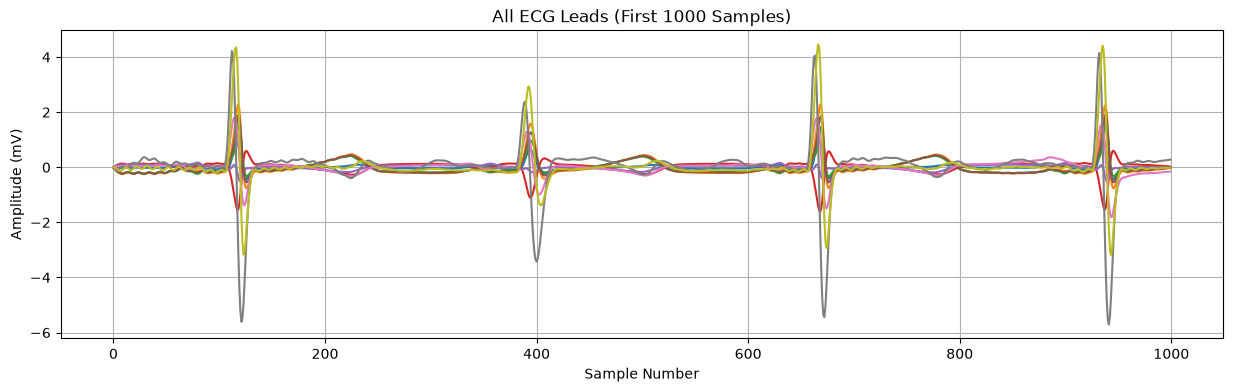

In [31]:
# ============================================================
# Visualize the ECG Waveform (First 1000 Samples)
# ------------------------------------------------------------
# This block plots the first 1000 samples of the ECG recording
# to provide an initial visualization of the signal.
#
# The ECG waveform is stored in `record.p_signal` as a 2D
# NumPy array with the following structure:
#
#     (number_of_samples, number_of_leads)
#
# The expression `record.p_signal[:1000]` selects the first
# 1000 samples from all available ECG leads. Since no lead
# index is specified, Matplotlib automatically plots every
# lead on the same graph, with each lead represented by a
# different colored line.
#
# Plotting only the initial portion of the recording makes it
# easier to observe the waveform morphology, heartbeat
# patterns, and differences in signal amplitude across the
# various ECG leads.
#
# The x-axis represents the sample number, while the y-axis
# represents the ECG amplitude in millivolts (mV).
#
# Note:
# The title "Lead II" is inaccurate for this code because all
# available leads are being plotted. To visualize only Lead II,
# replace the plotting command with:
#
#     plt.plot(record.p_signal[:1000, 1])
#
# Expected Output:
# A line plot displaying the first 1000 samples of all ECG
# leads in the recording.
# ============================================================

plt.figure(figsize=(15, 4))

plt.plot(record.p_signal[:1000])

plt.title("All ECG Leads (First 1000 Samples)")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude (mV)")

plt.grid(True)
plt.show()

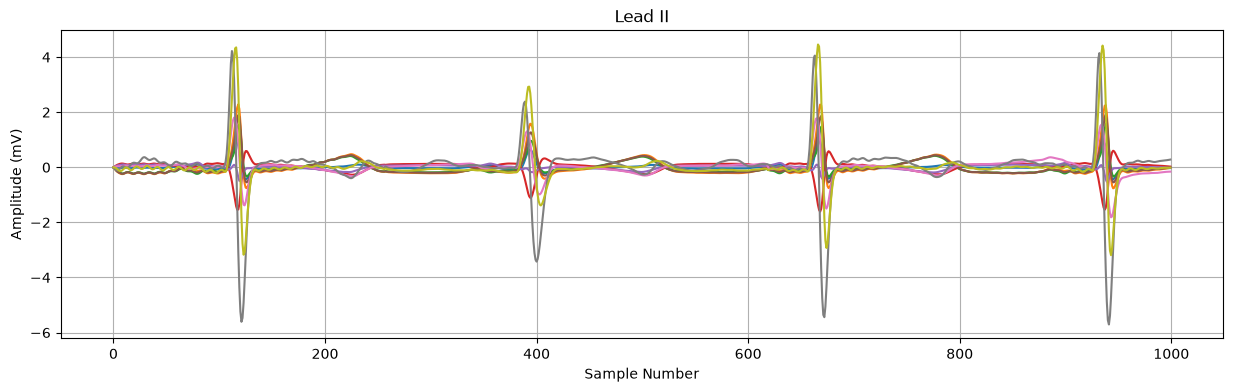

In [32]:
# ============================================================
# Visualize the ECG Waveform (First 1000 Samples)
# ------------------------------------------------------------
# This block generates a line plot of the first 1000 samples
# from the ECG recording to obtain an initial visual
# understanding of the signal.
#
# The ECG waveform is stored in `record.p_signal`, a 2D NumPy
# array with the following structure:
#
#     (number_of_samples, number_of_leads)
#
# The expression `record.p_signal[:1000]` selects the first
# 1000 samples from every available lead. Since no lead index
# is specified, Matplotlib automatically plots all lead
# signals on the same figure, with one line representing each
# ECG lead.
#
# The figure size is set to 15 × 4 inches to improve
# readability. Grid lines are enabled to make it easier to
# inspect waveform characteristics such as heartbeat
# intervals, peak amplitudes, and signal morphology.
#
# The x-axis represents the sample number, while the y-axis
# represents the ECG amplitude measured in millivolts (mV).
#
# Expected Output:
# A line plot displaying the first 1000 samples of the ECG
# recording for all available leads.
#
# Note:
# If the intention is to visualize only Lead II, the plotting
# command should be:
#
#     plt.plot(record.p_signal[:1000, 1])
#
# since Lead II corresponds to column index 1.
# ============================================================

plt.figure(figsize=(15, 4))

plt.plot(record.p_signal[:1000])

plt.title("Lead II")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude (mV)")

plt.grid(True)
plt.show()

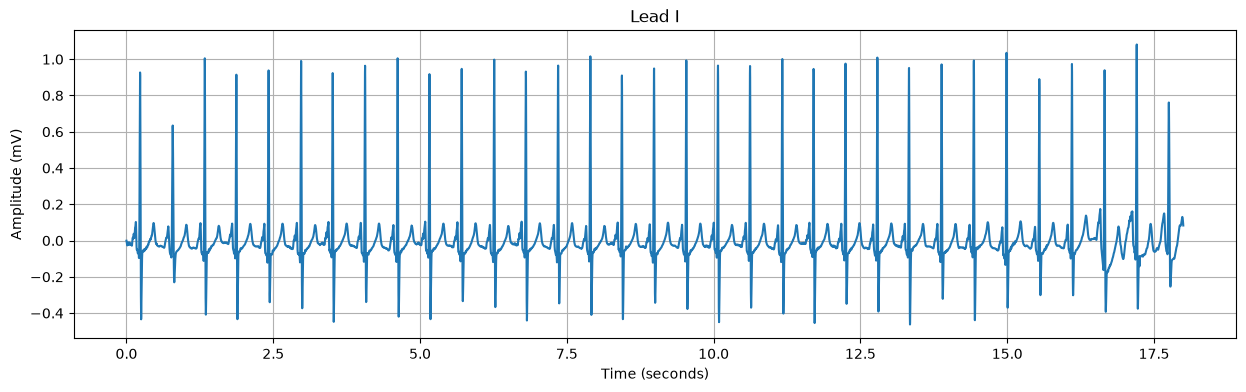

In [33]:
# ============================================================
# Plot the ECG Waveform Against Time
# ------------------------------------------------------------
# This block visualizes the ECG waveform of Lead I using time
# (in seconds) on the x-axis instead of sample number. Since
# ECG signals are sampled at a fixed frequency, converting the
# sample indices to time provides a more meaningful
# representation of the recording duration.
#
# The time vector is generated using:
#
#     np.arange(record.sig_len) / record.fs
#
# where:
# - `record.sig_len` is the total number of samples in the ECG
#   recording.
# - `np.arange(record.sig_len)` creates an array containing
#   sample indices from 0 to (sig_len - 1).
# - `record.fs` is the sampling frequency (samples per second).
# - Dividing the sample indices by the sampling frequency
#   converts each sample index into its corresponding time
#   value in seconds.
#
# The ECG signal is accessed using:
#
#     record.p_signal[:, 0]
#
# where:
# - `:` selects all recorded samples.
# - `0` selects the first ECG lead (Lead I).
#
# The resulting graph displays the complete ECG recording,
# allowing the duration of each heartbeat and the spacing
# between successive beats to be interpreted in real time.
#
# Expected Output:
# A line plot of Lead I with time (seconds) on the x-axis and
# ECG amplitude (mV) on the y-axis.
# ============================================================

time = np.arange(record.sig_len) / record.fs

plt.figure(figsize=(15, 4))
plt.plot(time, record.p_signal[:, 0])

plt.title("Lead I")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True)
plt.show()

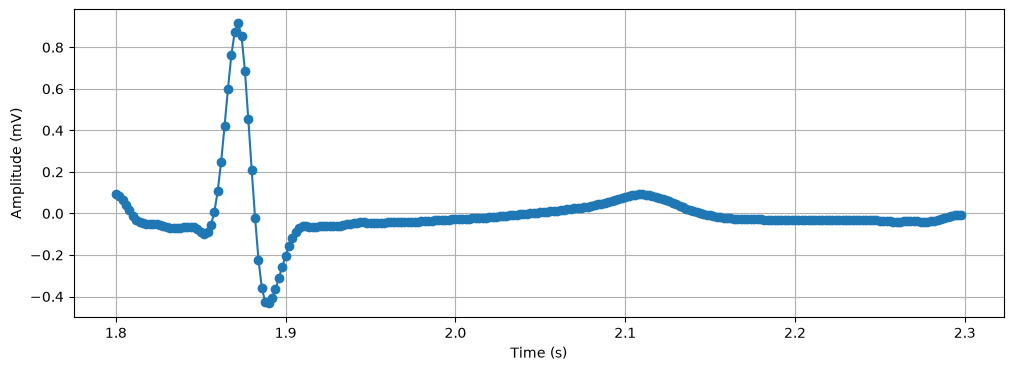

In [34]:
# ============================================================
# Zoom into a Single Heartbeat for Detailed ECG Inspection
# ------------------------------------------------------------
# This block visualizes a small segment of the ECG recording
# by plotting only a selected range of samples. Zooming into
# the signal makes it easier to inspect the morphology of an
# individual heartbeat, including the P wave, QRS complex,
# and T wave.
#
# The variables `start` and `end` define the range of sample
# indices to be displayed. Only the samples between these
# indices are extracted from the ECG recording.
#
# The x-axis uses the previously created `time` array, so the
# waveform is displayed against time (seconds) instead of
# sample number.
#
# The ECG signal is selected using:
#
#     record.p_signal[start:end, 0]
#
# where:
# - `start:end` selects a subset of samples.
# - `0` selects the first ECG lead (Lead I).
#
# The argument `marker='o'` places a circular marker at every
# recorded sample. This helps visualize the individual data
# points collected by the ECG machine and demonstrates that
# the seemingly vertical spikes seen in the full recording are
# actually formed by many closely spaced samples connected by
# straight line segments.
#
# This zoomed visualization is particularly useful for
# examining the shape, duration, and amplitude of individual
# cardiac cycles.
#
# Expected Output:
# A zoomed-in plot of Lead I showing a small time window of
# the ECG waveform with individual sample points marked.
# ============================================================

start = 900
end = 1150

plt.figure(figsize=(12, 4))
plt.plot(time[start:end], record.p_signal[start:end, 0], marker='o')

plt.grid(True)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")

plt.show()

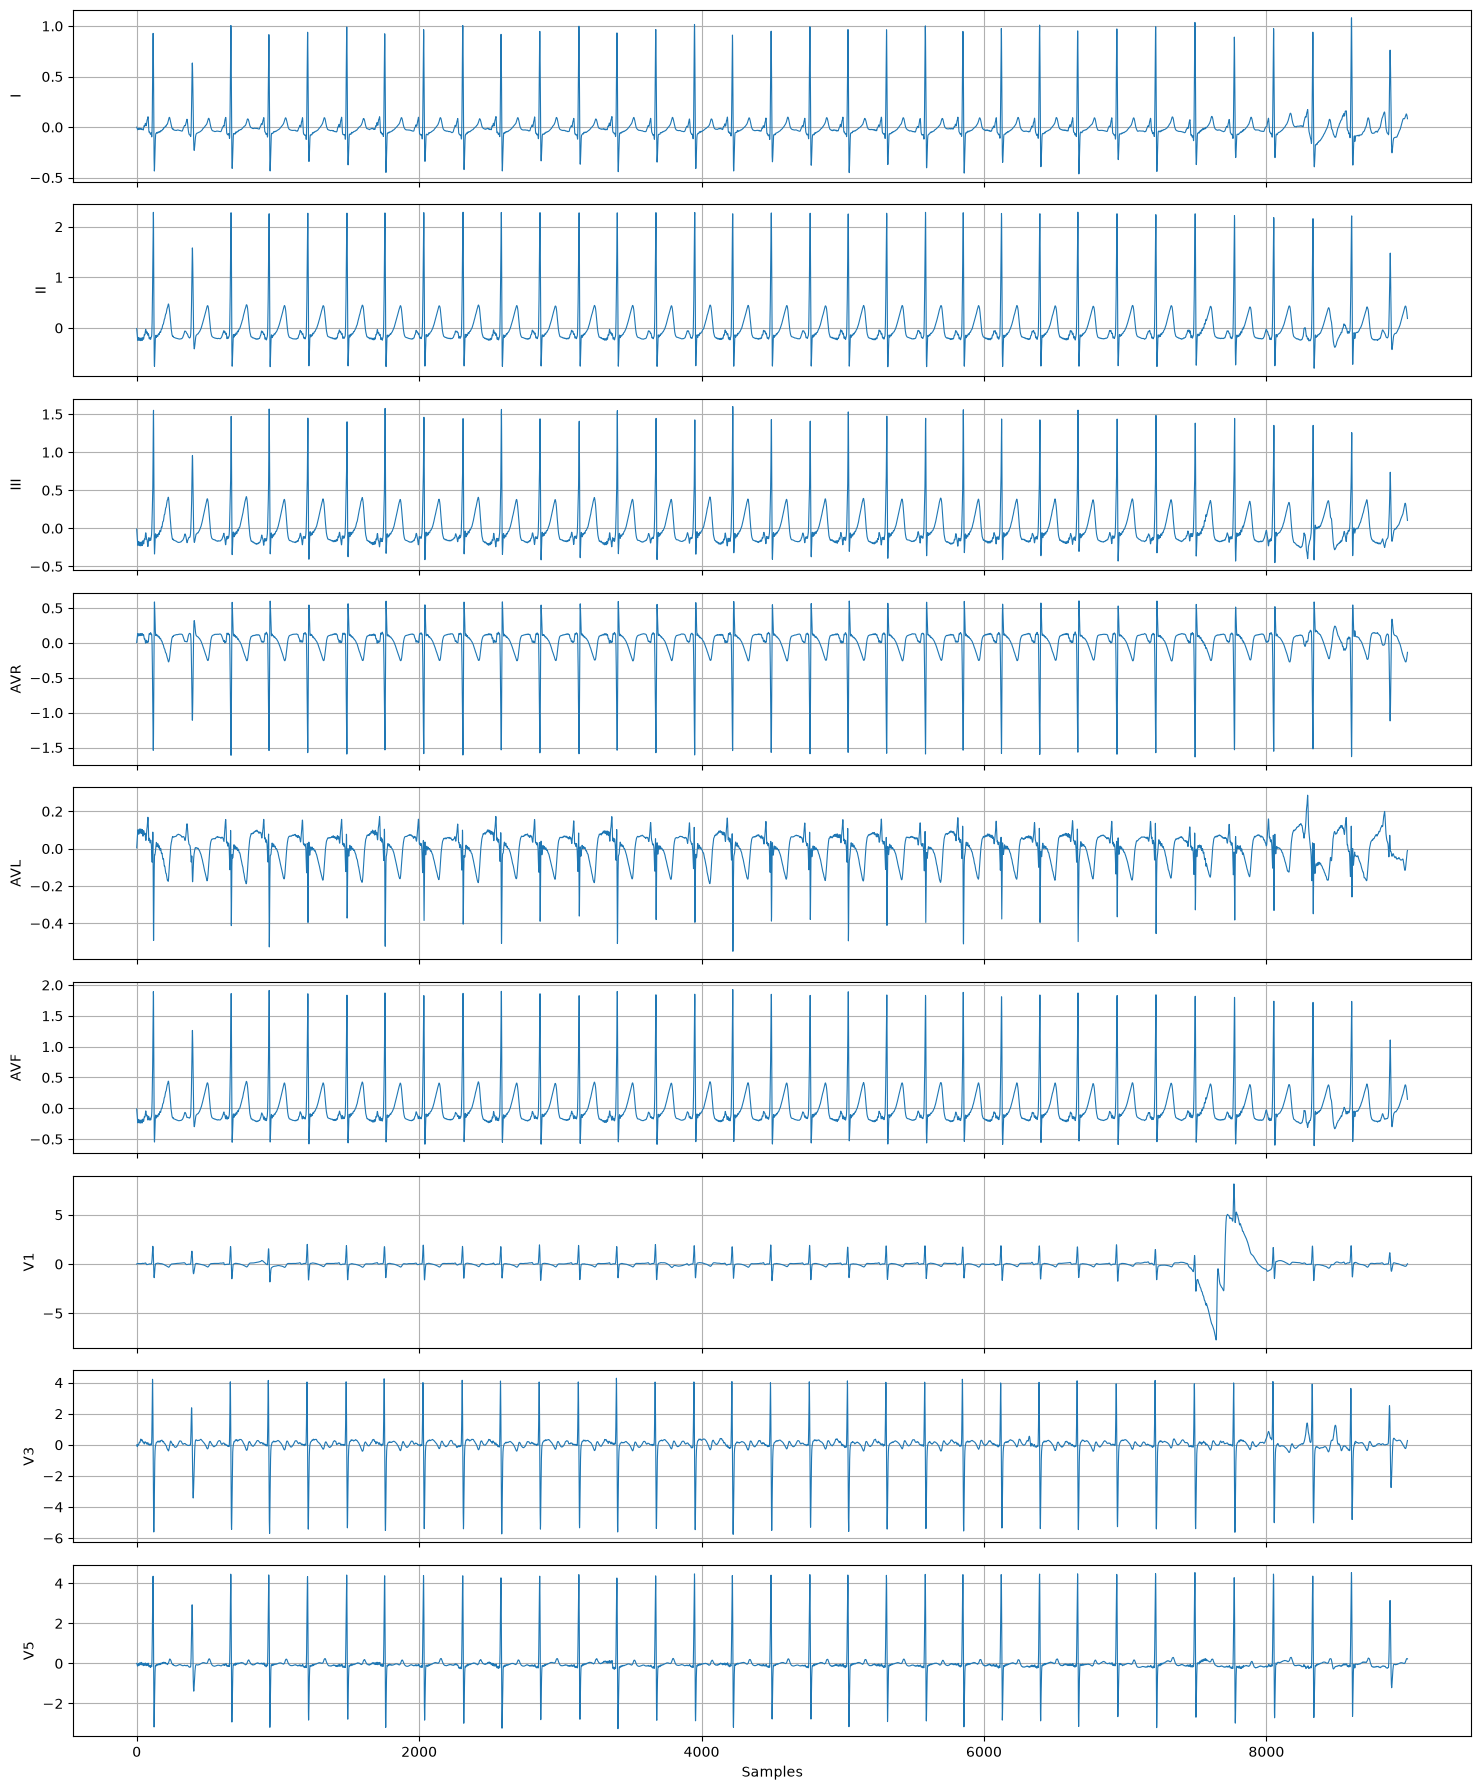

In [35]:
# ============================================================
# Visualize All ECG Leads Simultaneously
# ------------------------------------------------------------
# This block plots every ECG lead in a separate subplot,
# allowing the electrical activity of the heart to be
# examined from multiple viewpoints at the same time.
#
# The `plt.subplots()` function creates one subplot for each
# ECG lead (`record.n_sig`). The plots are arranged vertically
# in a single column and share the same x-axis so that the
# heartbeat timings can be compared directly across all leads.
#
# Parameters:
# - `record.n_sig` : Total number of ECG leads in the record.
# - `1`            : Creates a single column of subplots.
# - `figsize`      : Sets the overall figure size. The height
#                    is scaled according to the number of
#                    leads to prevent overlapping plots.
# - `sharex=True`  : Uses a common x-axis for every subplot,
#                    making it easier to compare the timing of
#                    cardiac events across different leads.
#
# The variable `time` computes the total duration of the ECG
# recording (in seconds) using:
#
#     total_duration = number_of_samples / sampling_frequency
#
# Although this value is not used further in this block, it
# represents the complete recording length and can be useful
# when plotting the ECG against time.
#
# The for-loop iterates through each ECG lead:
# - `record.p_signal[:, i]` extracts all samples for the
#   current lead.
# - `linewidth=0.8` produces a thinner waveform for improved
#   readability.
# - `set_ylabel()` labels each subplot with its corresponding
#   lead name (e.g., I, II, III, AVR, etc.).
# - `grid(True)` adds reference grid lines for easier visual
#   inspection.
#
# Finally, the bottom subplot is labeled with the x-axis
# ("Samples"), and `plt.tight_layout()` automatically adjusts
# the spacing between subplots to prevent overlapping labels.
#
# Expected Output:
# A vertically stacked set of ECG plots, one for each lead,
# sharing a common x-axis and clearly labeled with their
# respective lead names.
#
# Note:
# The variable `time` is calculated but not used in this code.
# It can be removed, or alternatively the x-axis can be
# changed to seconds by plotting against the time vector:
#
#     time = np.arange(record.sig_len) / record.fs
#     axes[i].plot(time, record.p_signal[:, i])
# ============================================================

fig, axes = plt.subplots(
    record.n_sig,
    1,
    figsize=(15, 2 * record.n_sig),
    sharex=True
)

time = record.p_signal.shape[0] / record.fs

for i in range(record.n_sig):
    axes[i].plot(record.p_signal[:, i], linewidth=0.8)
    axes[i].set_ylabel(record.sig_name[i])
    axes[i].grid(True)

axes[-1].set_xlabel("Samples")

plt.tight_layout()
plt.show()